<a href="https://colab.research.google.com/github/nikag2006/cap-comp215/blob/main/Ghassemi_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COMP 215 - PROJECT 2
----------------
#### Name: Nika Ghassemi
#### Date: Mar 25 2026

#### Cellular Automata: Pseudo-random Number Generator (Rule 30)

This project looks at using Rule 30 cellular automata as a pseudo-random number generator (PRNG). It involves improving the Cell1D class with a generator method, generating 32-bit random numbers, visualizing the results, and testing their randomness with a Monte Carlo approximation of π. It also compares the performance of the cellular automata-based PRNG with Python's built-in PRNG. This improves the generator using the middle column, and analyzes runtime and algorithm complexity.



In [ ]:
# Import modules
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import timeit

In [ ]:
# Helper Functions

# Powers of 2 for computing rule indexes
POWERS_OF_2 = np.array((4, 2, 1))

# I have changed the mode to "wrap".
def rule_indexes(state):
    """Return the rule index for each 3-cell neighborhood."""
    return np.correlate(np.pad(state, 1, mode='wrap'), POWERS_OF_2, mode='valid')

def transition(state, rule):
    """Return the next CA state under the given rule."""
    indexes = rule_indexes(state)
    return np.array(rule[indexes], dtype=np.uint8)

def get_lookup_table(rule):
    """Return the 8-bit lookup table for an elementary CA rule."""
    rule = np.array([rule], dtype=np.uint8)
    return np.unpackbits(rule)[::-1]

def single_centre_array(n_cells):
    """Return a binary array with one 1 in the center."""
    array = np.zeros(n_cells, dtype=np.uint8)
    array[n_cells // 2] = 1
    return array

def simulate_ca(n_cells, n_steps, rule):
    """Simulate a CA starting from a single active center cell."""
    start_state = single_centre_array(n_cells)
    ca_timesteps = np.vstack([
        start_state,
        np.zeros((n_steps - 1, len(start_state)), dtype=np.uint8)
    ])
    for t in range(1, n_steps):
        ca_timesteps[t] = transition(ca_timesteps[t - 1], rule)
    return ca_timesteps

def plot_ca(array, axes=None, title='', cmap='Blues', **options):
    """Plot CA states as a 2D image."""
    axes = axes or plt.gca()
    axes.set(title=title, ylabel='Time Steps')
    axes.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    options = {**dict(interpolation='nearest', origin='upper'), **options}
    axes.imshow(array, cmap=cmap, **options)

# I have added this function for binary to decimal conversion.
def bits_to_int(bits):
    """Convert a sequence of bits to a decimal integer."""
    bits = np.array(bits, dtype=np.uint8)
    powers = 2 ** np.arange(len(bits) - 1, -1, -1)
    return int(np.dot(bits, powers))

In [ ]:
# I have done some tests to validate the helper functions.
rule_110 = (0,1,1,0,1,1,1,0)[::-1]
assert np.all(get_lookup_table(110) == rule_110)
assert np.all(single_centre_array(7) == (0,0,0,1,0,0,0))
assert bits_to_int([1, 0, 1]) == 5

In [ ]:
# I have modified this Cell 1D class.
class Cell1D:
    """An elementary cellular automaton class."""
    def __init__(self, rule, start_state):
        self.rule_number = rule
        self.rule = get_lookup_table(rule)
        self.start_state = np.array(start_state, dtype=np.uint8)
        self.n_cells = len(start_state)
        self.ca_timesteps = np.array([self.start_state], dtype=np.uint8)
        self.n_steps = 1
        self.current_state = self.start_state.copy() # Added to keep cuurent_state from the start_state.

    def simulate(self, n_steps):
        """Simulate the CA for the given number of steps."""
        self.n_steps = n_steps
        self.ca_timesteps = np.vstack([
            self.start_state,
            np.zeros((n_steps - 1, self.n_cells), dtype=np.uint8)
        ])
        for t in range(1, self.n_steps):
          prev = self.ca_timesteps[t - 1]
          self.ca_timesteps[t] = transition(prev, self.rule)

    # Added method if we want to restart generation
    def reset(self):
        """Go back to the original starting state"""
        self.current_state = self.start_state.copy()

    # Added method for the next state
    def generate(self):
        """Yield the next CA state each time."""
        state = self.current_state.copy()
        while True:
            yield state.copy()
            state = transition(state, self.rule)
            self.current_state = state.copy()

    # Added method for moving steps forward
    def step(self):
        """Move forward one step and return the new state."""
        self.current_state = transition(self.current_state, self.rule)
        return self.current_state.copy()

    def draw(self, axes=None, title=''):
        """Draw the simulated CA."""
        plot_ca(self.ca_timesteps, axes=axes, title=f'Rule {self.rule_number}')

In [ ]:
# Simple Tests for the Cell1D class

# I have added this function to check that the generator returns the initial state and that the next state has the correct length.
def test_generate():
    start = np.array([0, 0, 0, 1, 0, 0, 0], dtype=np.uint8)
    ca = Cell1D(30, start)

    gen = ca.generate()
    first = next(gen)
    second = next(gen)

    assert np.array_equal(first, start)

    expected_second = transition(start, ca.rule)
    assert np.array_equal(second, expected_second)

# I have added this function to check that the generator produces the same states as the simulate() method.
def test_generate_matches_simulate():
    start = np.array([0, 1, 0, 1, 1, 0, 0, 1], dtype=np.uint8)

    ca1 = Cell1D(30, start)
    ca1.simulate(5)

    ca2 = Cell1D(30, start)
    gen = ca2.generate()

    states = []
    for _ in range(5): # Repeat 5 times
        states.append(next(gen))
    assert np.array_equal(ca1.ca_timesteps, states)

test_generate()
test_generate_matches_simulate()
print("Cell1D tests passed.")

Cell1D tests passed.


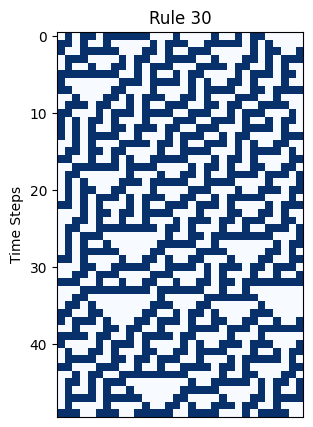

In [ ]:
# I have added this to visualize Rule 30
seed = np.random.randint(0, 2, size=32, dtype=np.uint8) # I created the 32-bit wide CA for Rule 30, seeded with a string of 32 bits
ca = Cell1D(30, seed)
ca.simulate(50)

plt.figure(figsize=(8, 5))
ca.draw(title='Rule 30')
plt.show()

## How to use Rule 30 as a PRNG

Rule 30 is a simple one-dimensional cellular automaton that creates complex and unpredictable patterns, which makes it useful for generating pseudo-random numbers. To use it as a PRNG, you start with an initial binary state (seed), apply Rule 30 repeatedly to produce new rows, take bits from each row, and convert them into integers to form a sequence of numbers.

In this project, I use two classes: one (Rand) generates numbers from the full row of cells, and another (Rand2) uses only the middle cell over multiple steps, which can give better randomness but takes more computation.

In [ ]:
# I have created PRNG classes
class Rand:
    """Uses rule 30 and converts the whole row into a number"""
    def __init__(self, seed_bits=None, width=32):
        if seed_bits is None:
            seed_bits = np.random.randint(0, 2, size=width, dtype=np.uint8)
        else:
            seed_bits = np.array(seed_bits, dtype=np.uint8)

        self.ca = Cell1D(30, seed_bits)

    def rand(self):
        """Get next state and turn it into an integer."""
        state = self.ca.step()
        return bits_to_int(state)

    def rand_list(self, n):
      """Generate n random numbers"""
      nums = []
      for _ in range(n):
        nums.append(self.rand())
      return nums

class Rand2:
    """Rule 30 PRNG using the middle bit from 32 steps."""
    def __init__(self, seed_bits=None, width=32):
        if seed_bits is None:
            seed_bits = np.random.randint(0, 2, size=width, dtype=np.uint8)
        else:
            seed_bits = np.array(seed_bits, dtype=np.uint8)

        self.ca = Cell1D(30, seed_bits)
        self.mid = width // 2
        self.width = width

    def rand(self):
        """Build a number from 32 middle bits."""
        bits = []
        for _ in range(self.width):
            state = self.ca.step()
            bits.append(state[self.mid])
        return bits_to_int(bits)

    def rand_list(self, n):
      """Generate n random numbers"""
      nums = []
      for _ in range(n):
        nums.append(self.rand())
      return nums

class PythonRand:
    """Uses Python's built-in PRNG."""
    def rand(self):
        return random.randint(0, 2**32 - 1)

In [ ]:
# I have added this test
rng = Rand()
print(rng.rand_list(10))

[495530330, 828369747, 3947891294, 2321030096, 3688116761, 303460151, 3207973092, 2699378079, 832430448, 1802572616]


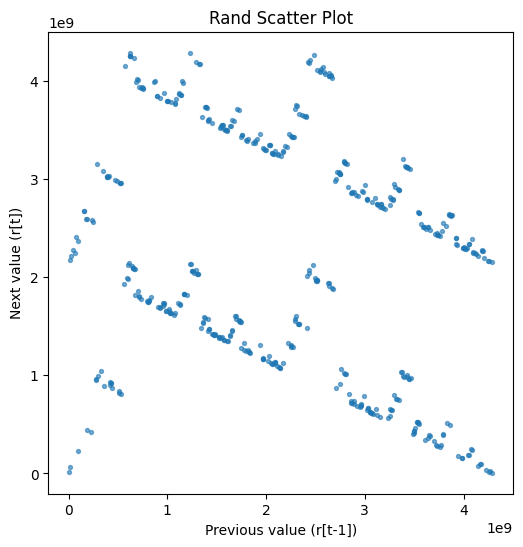

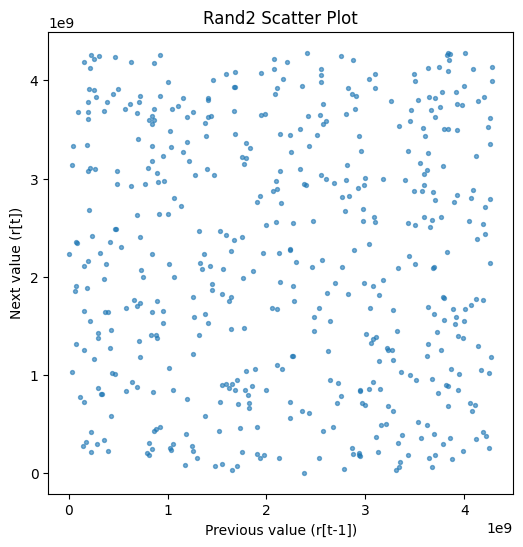

In [ ]:
# I have added this to show PRNG randomness with scatter plots.
def plot_rand_scatter(numbers, title="PRNG Scatter Plot"):
    """Plot consecutive random values as (r[t-1], r[t])."""
    x = numbers[:-1]
    y = numbers[1:]

    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, s=8, alpha=0.6)
    plt.xlabel("Previous value (r[t-1])")
    plt.ylabel("Next value (r[t])")
    plt.title(title)
    plt.show()

nums1 = Rand().rand_list(500)
plot_rand_scatter(nums1, title="Rand Scatter Plot")

nums2 = Rand2().rand_list(500)
plot_rand_scatter(nums2, title="Rand2 Scatter Plot")

## Observations - Rand Scatter Plot
The points in the plot are not spread out evenly; instead, they form noticeable diagonal patterns. These patterns suggest that there is some relationship between consecutive values ( r[t-1] ) and ( r[t] ), which means the numbers are not completely independent. Overall, the generator still produces values that look fairly random, but there is some mild clustering visible, showing that the randomness is not perfect.









## Observations - Rand2 Scatter Plot
These points are spread more uniformly across the plot compared to the Rand scatter plot, and the distribution appears more even overall. There are no clear diagonal lines or obvious patterns, which suggests that the correlation between consecutive values ( r[t-1] ) and ( r[t] ) is weaker. Based on this, Rand2 seems to produce better-quality random numbers than Rand, since the points look closer to what we would expect from true randomness.



In [ ]:
# I have added this to do Monte Carlo Test
MAX_UINT32 = 2**32 - 1

def monte_carlo_pi(prng, n):
    """Estimate pi using n random points."""
    inside = 0

    for _ in range(n):
        x = prng.rand() / MAX_UINT32
        y = prng.rand() / MAX_UINT32

        if math.sqrt(x**2 + y**2) < 1:
            inside += 1

    estimated_pi = 4 * inside / n # Use Monte Carlo pi formula: pi ≈ 4 * (inside/n)
    percent_error = abs(estimated_pi - math.pi) / math.pi * 100 # Computes percent error between estimated pi and actual pi (math.pi)
    return estimated_pi, percent_error

def get_pi_errors(prng_class, n_values):
    """Return a list of percent errors for different n values."""
    errors = []
    for n in n_values:
        prng = prng_class()
        _, err = monte_carlo_pi(prng, n) # _ is for ignoring the first returning value (estimated_pi)
        errors.append(err)
    return errors

In [ ]:
# Example pi estimate
pi_est, err = monte_carlo_pi(Rand(), 10000)
print("Estimated pi:", pi_est)
print("Percent error:", err,"%")

Estimated pi: 3.2388
Percent error: 3.094205937206124 %


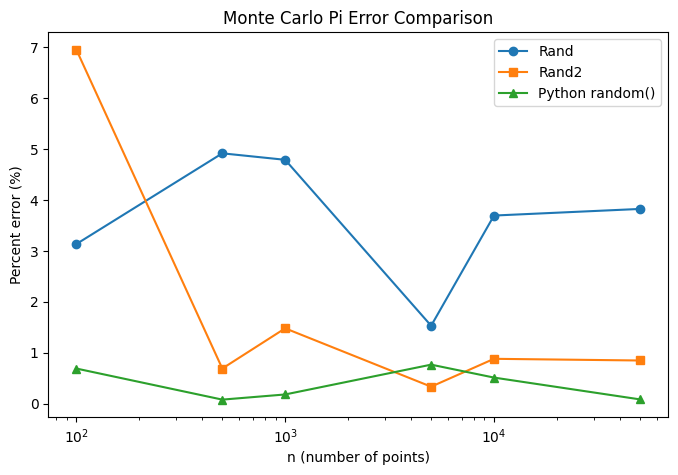

In [ ]:
# I have added this plot to compare Rand, Rand2, and Python random()
n_values = [100, 500, 1000, 5000, 10000, 50000]

rand_errors = get_pi_errors(Rand, n_values)
rand2_errors = get_pi_errors(Rand2, n_values)
python_errors = get_pi_errors(PythonRand, n_values)

plt.figure(figsize=(8, 5))
plt.plot(n_values, rand_errors, marker='o', label='Rand')
plt.plot(n_values, rand2_errors, marker='s', label='Rand2')
plt.plot(n_values, python_errors, marker='^', label='Python random()')
plt.xscale("log")
plt.xlabel("n (number of points)")
plt.ylabel("Percent error (%)")
plt.title("Monte Carlo Pi Error Comparison")
plt.legend()
plt.show()

### Observations - Monte Carlo Pi Error Comparison
The percent error generally decreases as the number of points increases for all three generators, which is expected when using Monte Carlo methods. Python’s built-in random generator consistently shows the lowest error across most values of n, indicating better accuracy compared to the other two methods. Rand2 performs better than Rand in most cases, especially as the number of points increases, since its error drops to relatively low values. Rand also improves as n increases, but its error remains higher and fluctuates more than the others, suggesting that it produces random numbers but is less reliable than Rand2 and Python’s built-in generator.




In [ ]:
# I have added this to measure how fast Rand and Rand2 are.
def time_rand():
    rng = Rand()
    for _ in range(1000):
        rng.rand()

def time_rand2():
    rng = Rand2()
    for _ in range(1000):
        rng.rand()

t_rand = timeit.timeit(time_rand, number=10)
t_rand2 = timeit.timeit(time_rand2, number=10)

print("Rand time: ", t_rand)
print("Rand2 time:", t_rand2)
print("Rand2 / Rand ratio:", t_rand2 / t_rand) # Multiplicative penalty of the algorithm

Rand time:  0.6085037699995155
Rand2 time: 12.289125650000642
Rand2 / Rand ratio: 20.195644227496615


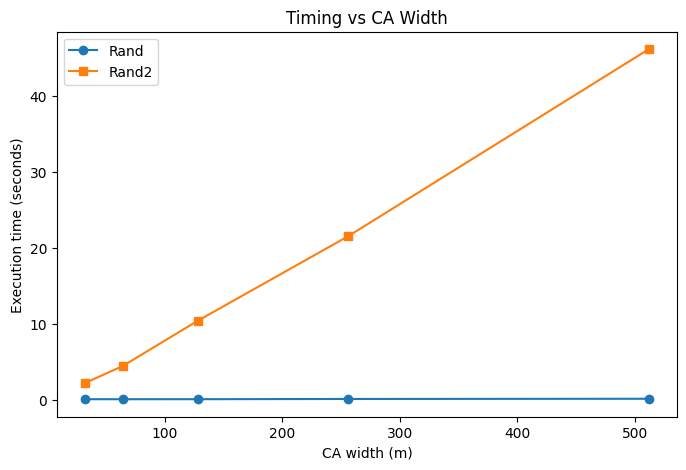

In [ ]:
# I have added this to compare execution time of Rand and Rand2 at different widths.
def time_rand_width(width, num_steps=500):
  """Measure execution time for generating random numbers."""
  def run():
    rng = Rand(width=width)
    for _ in range(num_steps):
        rng.rand()
  return timeit.timeit(run, number=5)

def time_rand2_width(width, num_steps=500):
  """Measure execution time for generating random numbers with Rand2."""
  def run():
    rng = Rand2(width=width)
    for _ in range(num_steps):
        rng.rand()
  return timeit.timeit(run, number=5)

widths = [32, 64, 128, 256, 512]

rand_times = [time_rand_width(w) for w in widths]
rand2_times = [time_rand2_width(w) for w in widths]

plt.figure(figsize=(8, 5))
plt.plot(widths, rand_times, marker='o', label='Rand')
plt.plot(widths, rand2_times, marker='s', label='Rand2')
plt.xlabel("CA width (m)")
plt.ylabel("Execution time (seconds)")
plt.title("Timing vs CA Width")
plt.legend()
plt.show()

## Observation - Timing vs CA Width
The execution time clearly increases as the CA width increases for Rand2, showing that larger widths require more computation. For Rand, the execution time stays very low and appears almost flat on this scale, so the increase is not clearly visible in the plot. This still agrees with the expected O(m) behavior, but for Rand the running time is so small that the change is hard to notice. Rand2 consistently takes much more time than Rand because it performs many CA updates for each generated number.



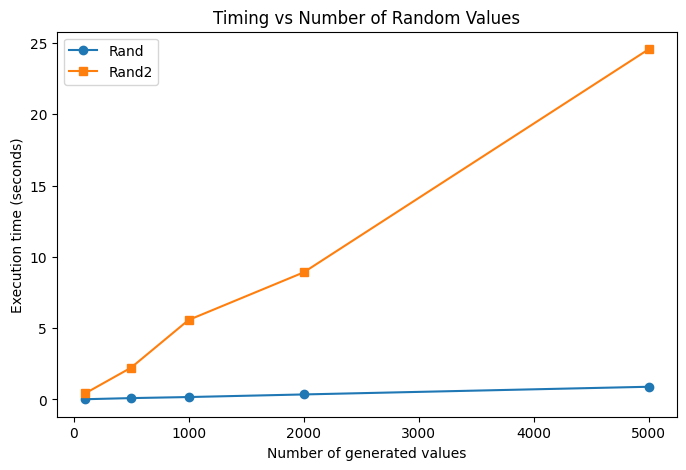

In [ ]:
# I have added this to see how long it takes to generate different random values.
counts = [100, 500, 1000, 2000, 5000]

def measure_by_count(prng_class, counts, width=32):
    """Measure execution time for generating random numbers."""
    times = []

    for count in counts:
        def run():
            rng = prng_class(width=width)
            for _ in range(count):
                rng.rand()

        times.append(timeit.timeit(run, number=5))
    return times

rand_times = measure_by_count(Rand, counts, width=32)
rand2_times = measure_by_count(Rand2, counts, width=32)

plt.figure(figsize=(8, 5))
plt.plot(counts, rand_times, marker='o', label='Rand')
plt.plot(counts, rand2_times, marker='s', label='Rand2')
plt.xlabel("Number of generated values")
plt.ylabel("Execution time (seconds)")
plt.title("Timing vs Number of Random Values")
plt.legend()
plt.show()

## Observation - Timing vs Number of Random Values
The execution time increases as the number of generated values increases for both Rand and Rand2, showing that generating more random numbers requires more computation. However, Rand2 takes significantly more time than Rand at all points, and its execution time increases much faster as the number of values grows. In contrast, the execution time for Rand increases slowly and remains relatively low throughout the test. This suggests that while both generators scale with the number of generated values, Rand2 requires much more computation in practice because it performs multiple cellular automaton updates for each random number.
  





## Algorithm Analysis

For a cellular automaton (CA) with width m, each step updates all m cells. Because of this, one step takes O(m) time. If we generate n generations, the total time becomes O(nm) since we repeat that step n times.

For Rand, each call to rand() performs one CA step and then converts the row of bits into an integer. Since both operations depend on the number of cells, each call to rand() takes O(m) time.

For Rand2, each call to rand() performs 32 CA steps to collect 32 middle bits. This makes the cost O(32m). In Big-O notation, this is still written as O(m) because constants are ignored. However, in practice, Rand2 takes noticeably longer because it repeats the CA step many more times, so it has a much larger constant factor.

The timing results from the simulations support this analysis. When comparing execution times, Rand2 consistently took longer than Rand, and the ratio between their running times was roughly consistent with the extra number of CA steps required. In addition, when increasing the CA width m, the execution time increased approximately linearly for both Rand and Rand2, which confirms the predicted O(m) behavior.

## PRNG Notes

* Rule 30 cellular automata are used to generate pseudo-random values.

* The generator begins with a binary seed and updates the row using Rule 30 at each step.

* Rand converts the full row into an integer, while Rand2 uses repeated middle-bit sampling to build integers.

* Scatter plots visualize relationships between consecutive values.

* Monte Carlo π testing evaluates randomness quality.

* Python's built-in random generator is used for comparison.

* Runtime measurements confirm expected linear performance behavior.